In [11]:
from simfile import SimFile
from simulation import Simulation
from validation import switchOffAllEffects
import os
import numpy as np
import matplotlib.pyplot as plt
import math
from matplotlib.patches import ConnectionPatch

In [12]:
sim = Simulation("Flatfielding")
switchOffAllEffects(sim)
sim.outputDir = os.environ["PLATO_WORKDIR"]

In [15]:
# One full-frame exposure

sim["ObservingParameters/NumExposures"] = 1
sim["SubField/NumRows"] = 4510
sim["SubField/NumColumns"] = 4510

# Enable flatfielding

sim["CCD/IncludeFlatfield"] = "yes"
rms = sim["CCD/FlatfieldNoiseRMS"]

# Make sure no sources are located in the sub-field

sim["ObservingParameters/DecPointing"] = -sim["ObservingParameters/DecPointing"]

sim["ControlHDF5Content/WriteSubPixelImages"] = "true"

output = sim.run(removeOutputFile = True)

image = output.getImage(0)


2019-05-28 11:16:03 WARNING Simulation: no information about detected stars to write to HDF5
2019-05-28 11:16:03 WARNING Camera: No star positions to write to HDF5 file.



# PRNU derived directly from the image

In [16]:
mean = np.mean(image)
prnuFromImage = math.sqrt(np.mean((image - mean)**2)) / mean

print("PRNU derived from PlatoSim output:", prnuFromImage)
print("To compare with input value in the configuration file:", rms)

PRNU derived from PlatoSim output: 0.010100039984005887
To compare with input value in the configuration file: 0.01


# Flatfield map

In [5]:
flatfield = output.getPRNU()

## Histogram

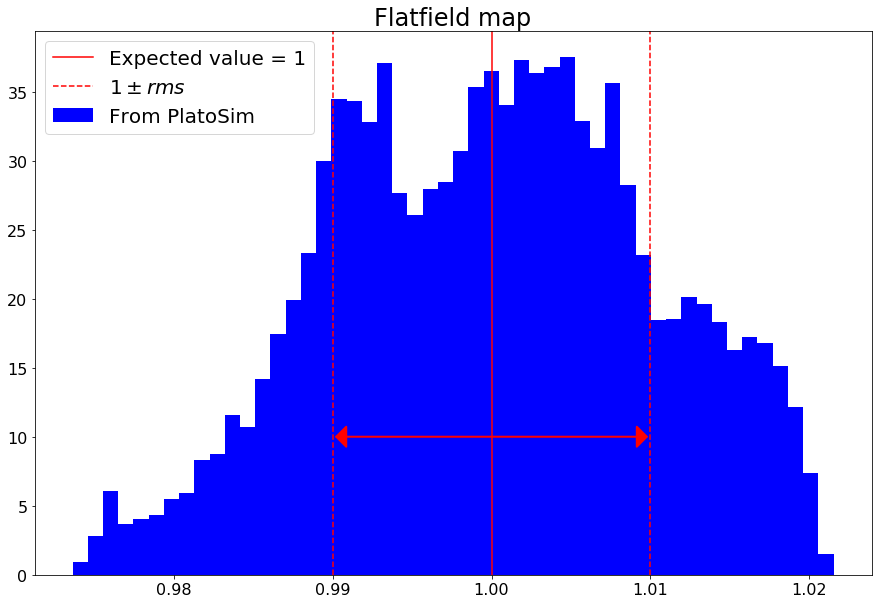

In [6]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

plt.hist(np.ravel(flatfield), 50, density = True, color = "b", label = "From PlatoSim")



#################
# Expected values
#################

plt.axvline(x = 1, color = "r", label = "Expected value = 1")
plt.axvline(x = 1 - rms, color ="r", linestyle = "dashed", label = "$1 \\pm rms$")
plt.axvline(x = 1 + rms, color = "r", linestyle = "dashed")
ax.annotate("",
            xy=(1 - rms, 10), xycoords='data',
            xytext=(1 + rms, 10), textcoords='data',
            arrowprops=dict(arrowstyle="<|-|>, head_width = 1, head_length = 1",
                            connectionstyle="arc3", color="r", lw="2")
            )



########
# Layout
########

plt.title("Flatfield map", fontsize = 24)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)

## Mean & standard deviation

In [7]:
meanFromFlatfieldMap = np.mean(flatfield)
stdDevFromFlatfieldMap = np.std(flatfield)

print("Mean from flatfield map:", meanFromFlatfieldMap)
print("To compare with expected value:", 1, "\n")

print("Standard deviation from flatfield map:", stdDevFromFlatfieldMap)
print("To compare with input value in the configuration file:", rms)

Mean from flatfield map: 0.99998665
To compare with expected value: 1 

Standard deviation from flatfield map: 0.0100999
To compare with input value in the configuration file: 0.01


## 1 / f dependency

In [8]:
fft = np.fft.fft2(flatfield)
realPart = np.real(fft)

# Comparison

In [9]:
image = output.getSubPixelImage(0)

sim["CCD/IncludeFlatfield"] = "no"
output = sim.run(removeOutputFile = True)
refImage = output.getSubPixelImage(0)

Error: SimFile.getSubPixelImage(): there is no SubPixelImages group in the HDF5 file


Error: SimFile.getSubPixelImage(): there is no SubPixelImages group in the HDF5 file


In [10]:
quotient = image / refImage

TypeError: unsupported operand type(s) for /: 'NoneType' and 'NoneType'